In [1]:
import pandas as pd
import matplotlib.pyplot as plt

sanctions = pd.read_csv('../data/sanctions/ofac_sdn.csv')
print(f"Total sanctions entries: {len(sanctions):,}")
print(f"\nSanction programs (top 10):")
print(sanctions['sanction_program'].value_counts().head(10))
print(f"\nName length distribution:")
print(sanctions['name'].str.len().describe())

Total sanctions entries: 7,469

Sanction programs (top 10):
sanction_program
RUSSIA-EO14024           1597
SDGT                     1316
SDNTK                     728
ILLICIT-DRUGS-EO14059     270
GLOMAG                    247
NPWMD] [IFSR              222
VENEZUELA                 157
BALKANS                   148
IRAQ2                     138
IRAN-HR                   138
Name: count, dtype: int64

Name length distribution:
count    7469.000000
mean       22.945106
std         7.348811
min         6.000000
25%        16.000000
50%        24.000000
75%        29.000000
max        59.000000
Name: name, dtype: float64


In [2]:
kyc = pd.read_csv('../data/processed/kyc_onboarding_dataset.csv')
print(f"Total records: {len(kyc):,}")
print(f"High-risk rate: {kyc['is_high_risk'].mean()*100:.2f}%")
print()
print("Compare to Project 1's 0.297% fraud rate:")
print("KYC risk is inherently more common — most flagged cases are")
print("legitimate customers needing enhanced verification, not confirmed")
print("bad actors. This shapes the decision tiers: REJECT should be rare,")
print("REVIEW should be the dominant 'flagged' outcome.")

Total records: 50,000
High-risk rate: 0.65%

Compare to Project 1's 0.297% fraud rate:
KYC risk is inherently more common — most flagged cases are
legitimate customers needing enhanced verification, not confirmed
bad actors. This shapes the decision tiers: REJECT should be rare,
REVIEW should be the dominant 'flagged' outcome.


Feature correlation with is_high_risk:
is_high_risk                 1.000000
dob_mismatch                 0.358965
sanctions_name_similarity    0.068385
is_pep_match                 0.066157
device_fingerprint_reuse     0.032184
onboarding_attempts_24h      0.027302
ip_country_mismatch          0.006349
phone_country_mismatch       0.004104
email_domain_age_days        0.002325
name_match_score            -0.037045
document_quality_score      -0.083605
Name: is_high_risk, dtype: float64


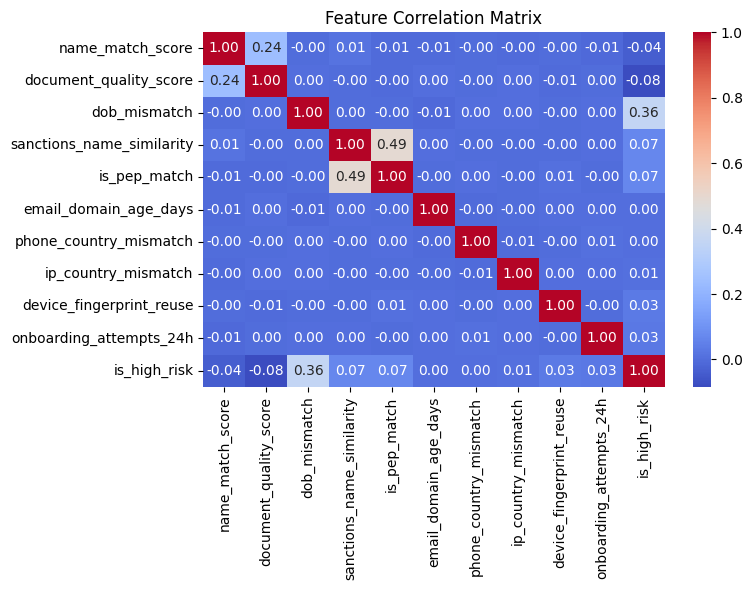

In [3]:
import seaborn as sns

numeric_cols = [
    'name_match_score', 'document_quality_score', 'dob_mismatch',
    'sanctions_name_similarity', 'is_pep_match', 'email_domain_age_days',
    'phone_country_mismatch', 'ip_country_mismatch',
    'device_fingerprint_reuse', 'onboarding_attempts_24h', 'is_high_risk'
]
corr = kyc[numeric_cols].corr()['is_high_risk'].sort_values(ascending=False)
print("Feature correlation with is_high_risk:")
print(corr)

plt.figure(figsize=(8, 6))
sns.heatmap(kyc[numeric_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

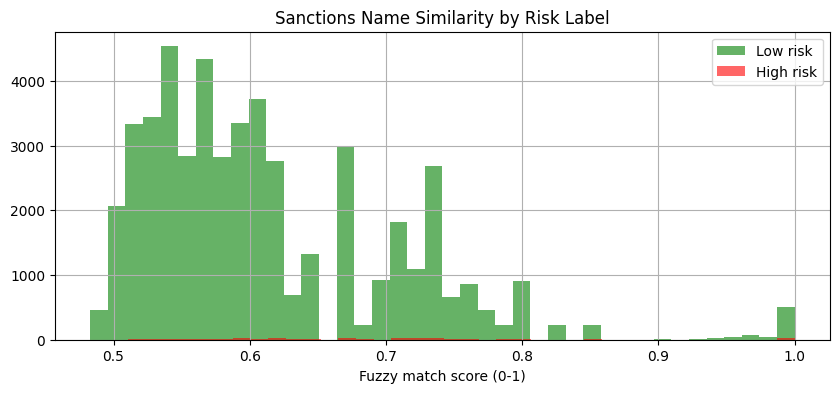

SANCTIONS_MATCH_THRESHOLD in .env is set to 85 (0.85).
This chart shows whether that threshold separates the
populations well, or needs adjustment in Phase 4.


In [4]:
# How does sanctions_name_similarity distribute for high-risk vs low-risk?
fig, ax = plt.subplots(figsize=(10, 4))
kyc[kyc['is_high_risk']==0]['sanctions_name_similarity'].hist(
    bins=40, alpha=0.6, label='Low risk', ax=ax, color='green'
)
kyc[kyc['is_high_risk']==1]['sanctions_name_similarity'].hist(
    bins=40, alpha=0.6, label='High risk', ax=ax, color='red'
)
ax.set_title('Sanctions Name Similarity by Risk Label')
ax.set_xlabel('Fuzzy match score (0-1)')
ax.legend()
plt.show()

print("SANCTIONS_MATCH_THRESHOLD in .env is set to 85 (0.85).")
print("This chart shows whether that threshold separates the")
print("populations well, or needs adjustment in Phase 4.")